In [1]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential 
#import optimizer and loss function
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
train_generator = ImageDataGenerator(rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True)
train_data = train_generator.flow_from_directory(r'C:\Users\HP\Desktop\Deep_learning\datasets\Training', target_size=(256, 256), batch_size=32, class_mode='categorical')

Found 5600 images belonging to 4 classes.


In [3]:
test_generator = ImageDataGenerator(rescale=1./255)
test_data = test_generator.flow_from_directory(r'C:\Users\HP\Desktop\Deep_learning\datasets\Testing', target_size=(256, 256), batch_size=32, class_mode='categorical')

Found 1600 images belonging to 4 classes.


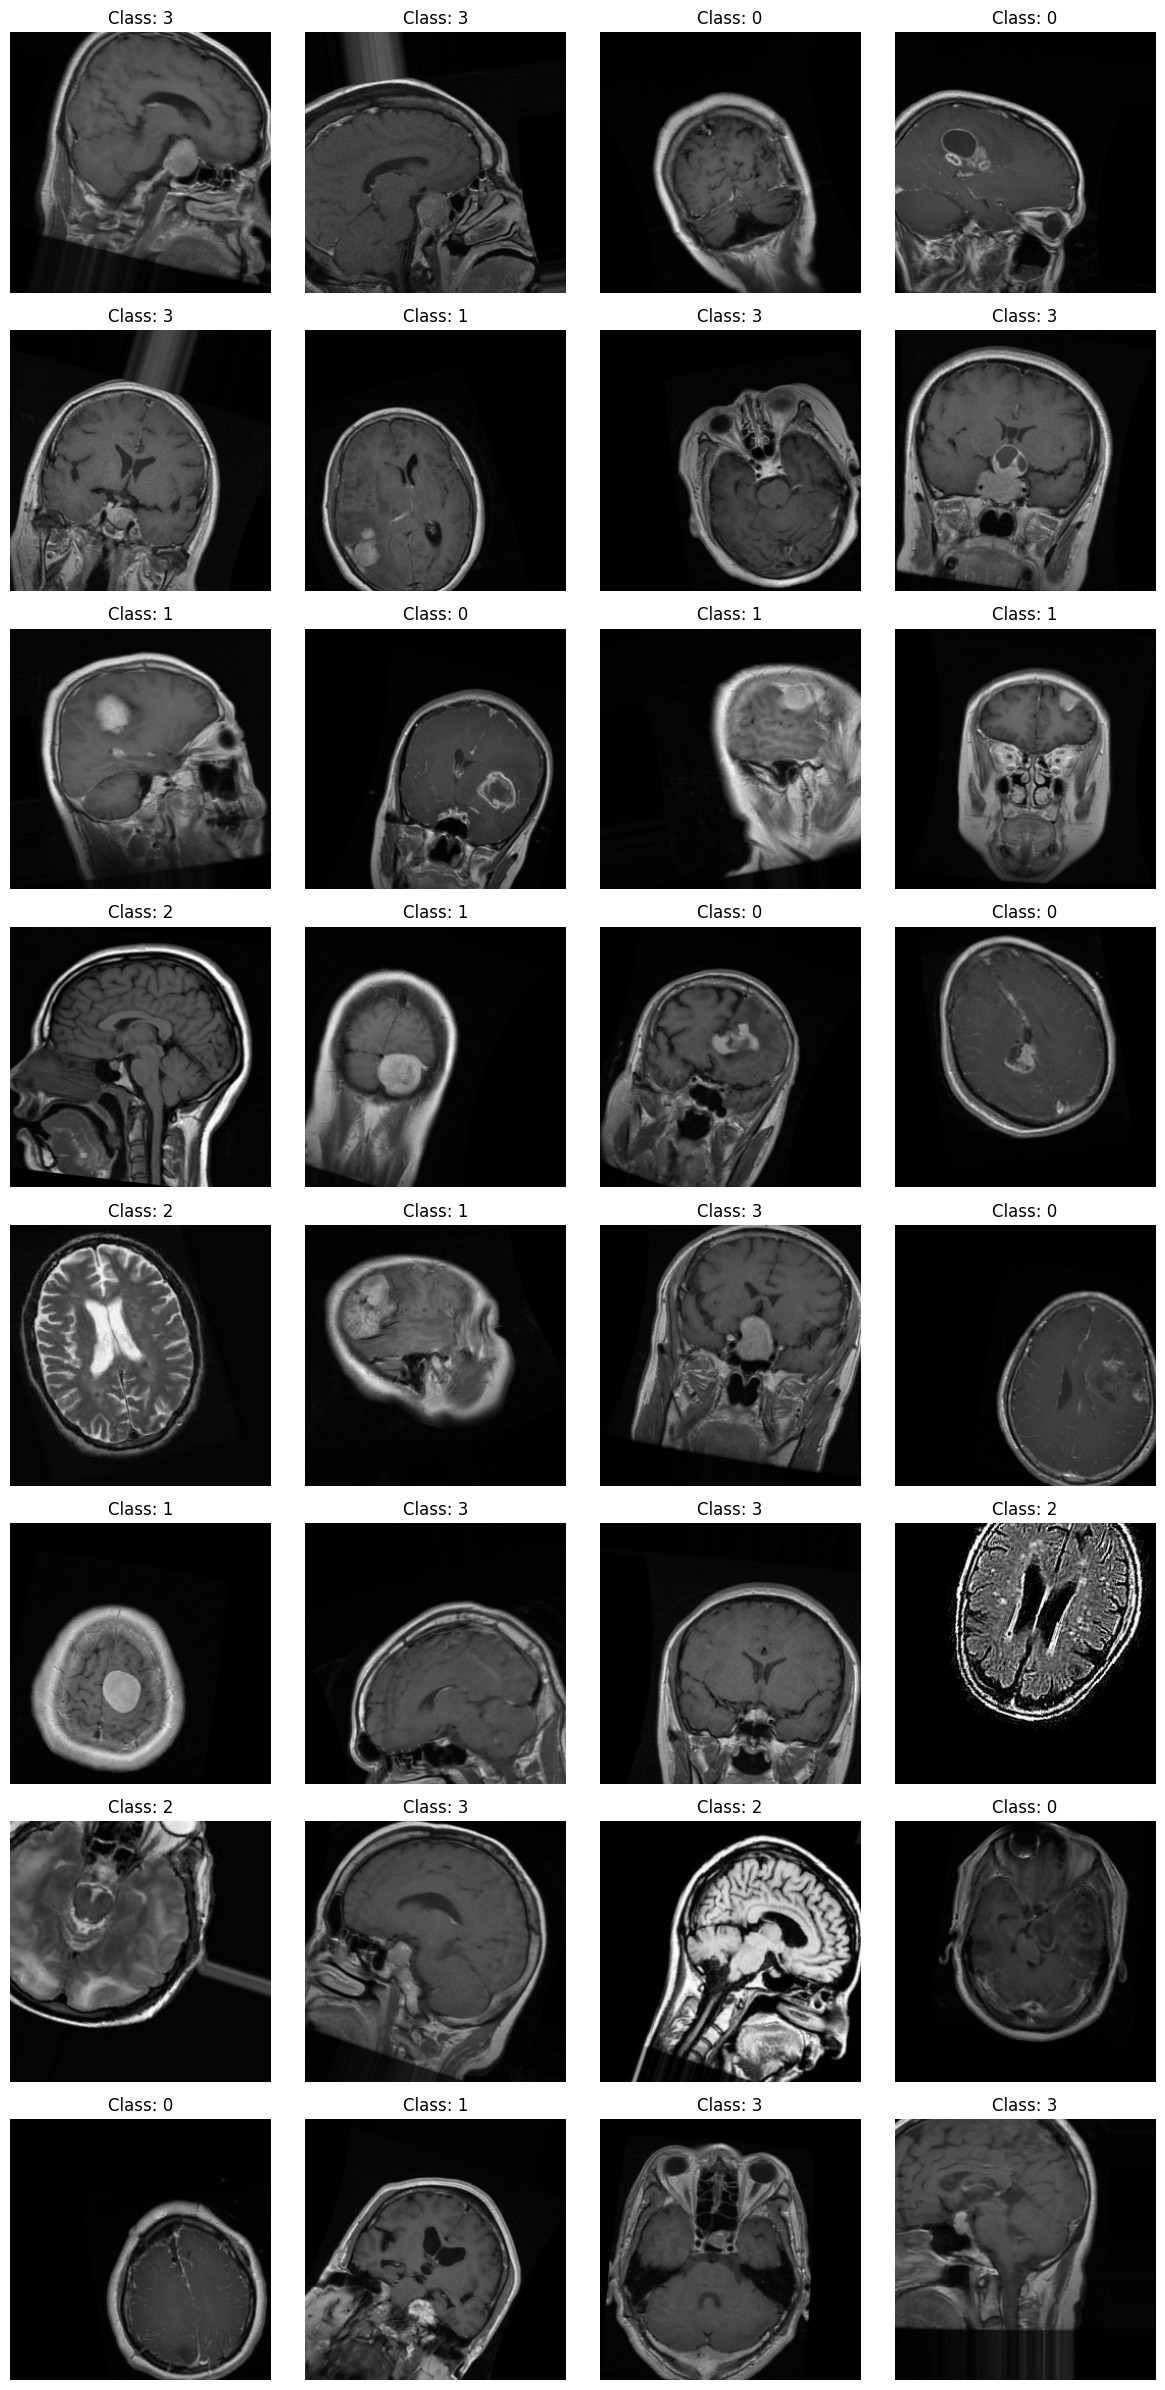

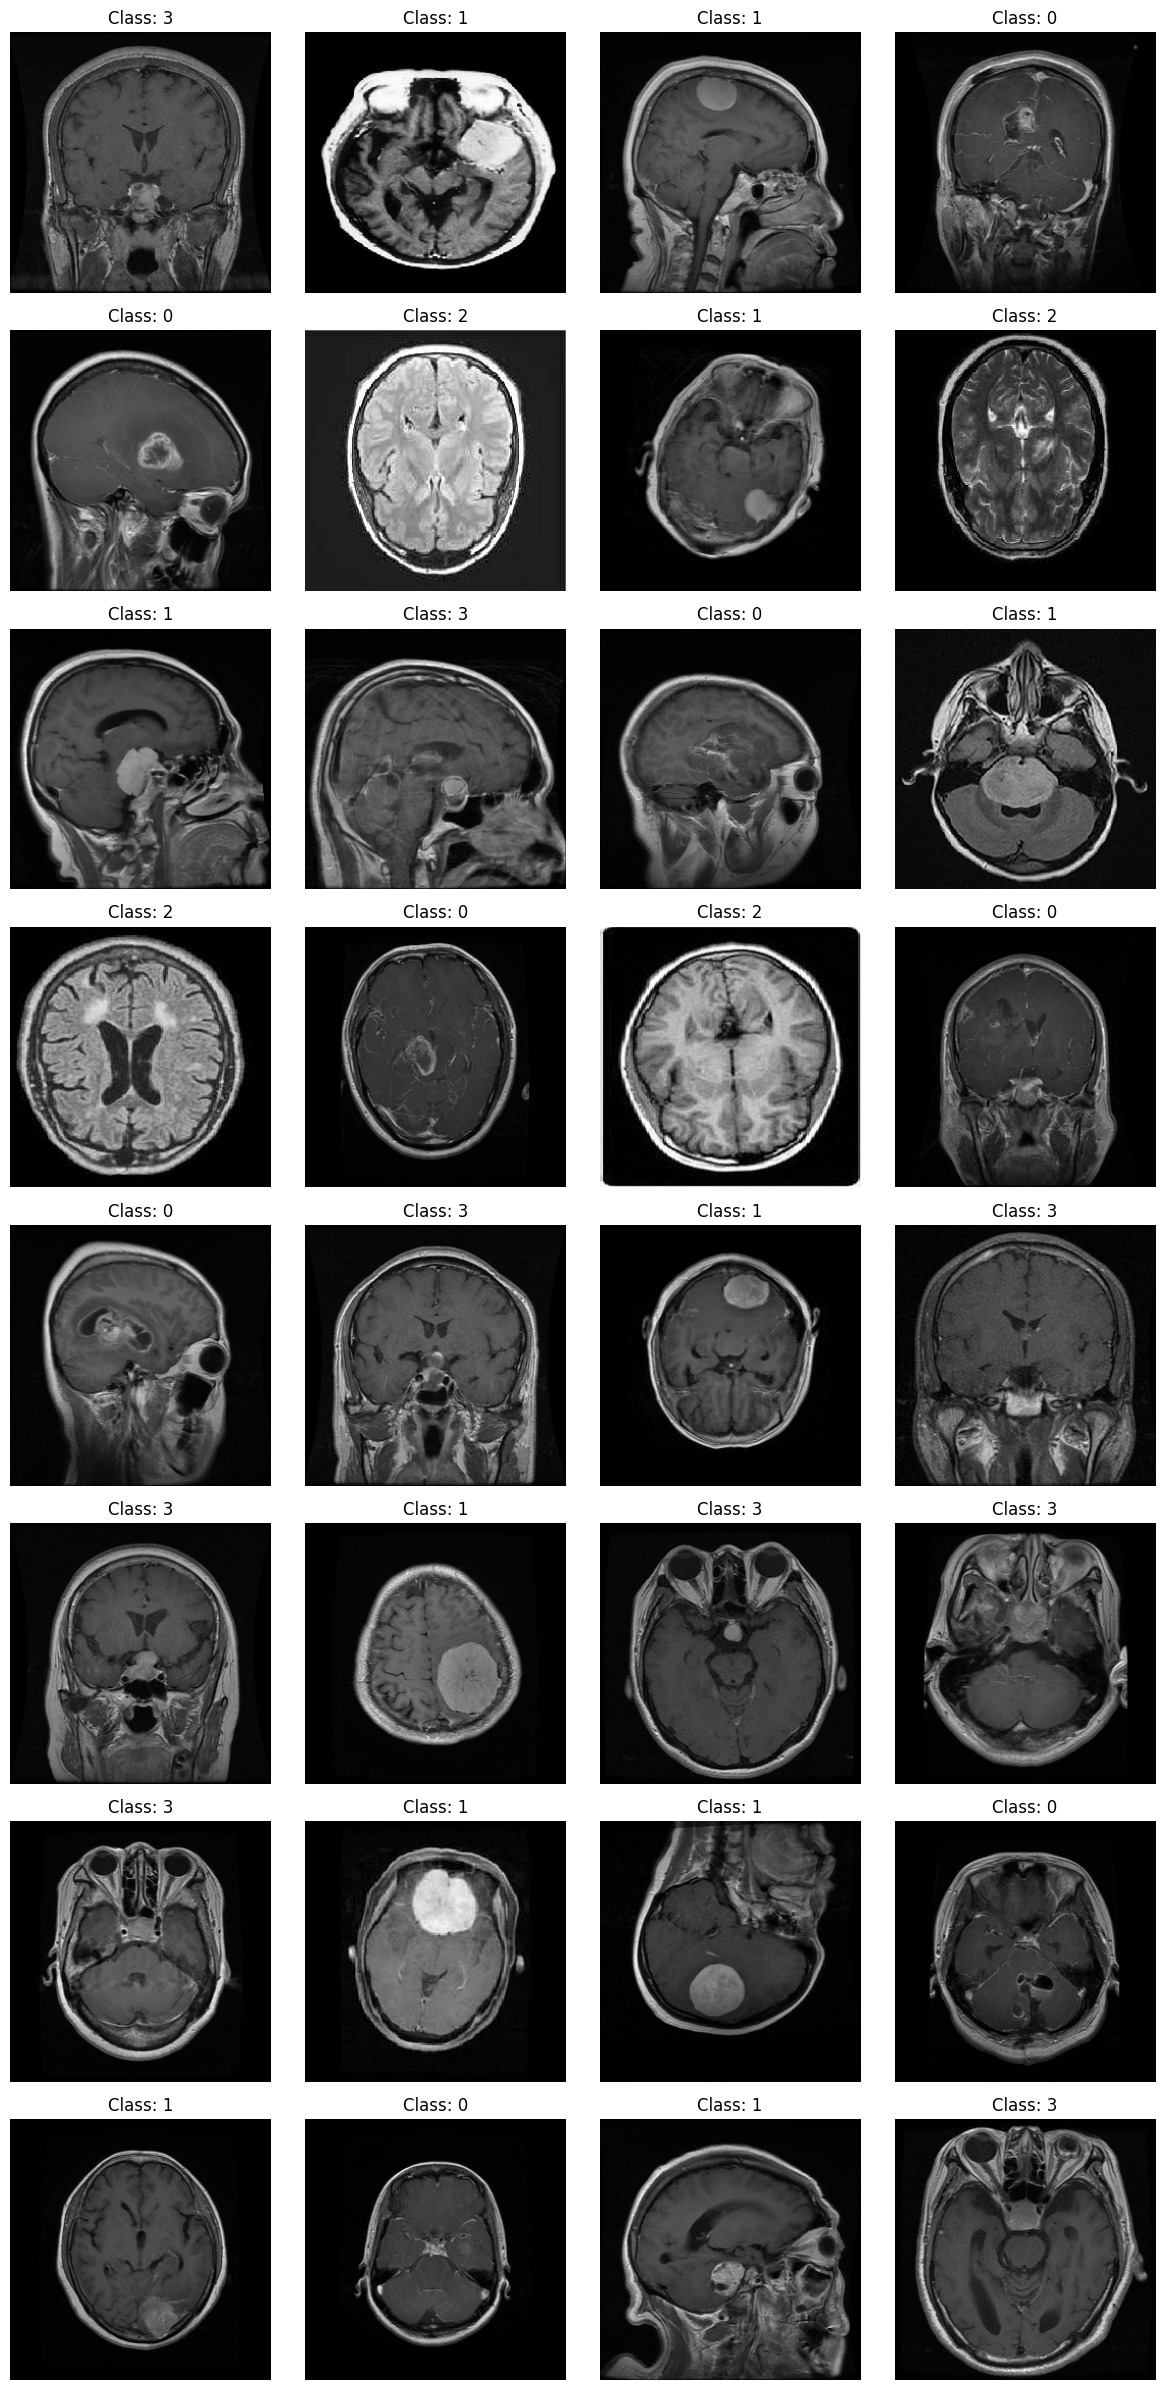

In [ ]:
#@title Plotting an images
import math
# Function to plot images
def plot_images(images, labels):
    num_images = images.shape[0]
    num_rows = int(math.ceil(num_images / 4))
    fig, axes = plt.subplots(num_rows, 4, figsize=(12, 3 * num_rows))
    for i in range(num_images):
        row = i // 4
        col = i % 4
        axes[row, col].imshow(images[i])
        axes[row, col].set_title(f"Class: {np.argmax(labels[i])}")
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()


# Get a batch of training images and labels
train_images, train_labels = next(train_data)

# Get a batch of testing images and labels
test_images, test_labels = next(test_data)

# Plot a few images from the training and testing data
import matplotlib.pyplot as plt
import numpy as np
plot_images(train_images, train_labels)
plot_images(test_images, test_labels)



In [4]:
#CNN 
#conv---pooling---conv---pooling---flatten---dense---output
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='relu'),
    Dense(4, activation='softmax')
])

c:\Users\HP\Desktop\Deep_learning\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
#optimizers and loss function
model_compile = model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
print(model.input_shape)

(None, 256, 256, 3)


In [8]:
History = model.fit(train_data, epochs=30, validation_data=test_data, verbose=1)

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 142s 804ms/step - accuracy: 0.3355 - loss: 1.3119 - val_accuracy: 0.4238 - val_loss: 1.1897
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 138s 790ms/step - accuracy: 0.4257 - loss: 1.1410 - val_accuracy: 0.4194 - val_loss: 1.4254
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 140s 798ms/step - accuracy: 0.4511 - loss: 1.1183 - val_accuracy: 0.6156 - val_loss: 1.2185
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 131s 750ms/step - accuracy: 0.4854 - loss: 1.0629 - val_accuracy: 0.5838 - val_loss: 1.1858
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 137s 780ms/step - accuracy: 0.4770 - loss: 1.0832 - val_accuracy: 0.6344 - val_loss: 1.2438
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 154s 879ms/step - accuracy: 0.5004 - loss: 1.0462 - val_accuracy: 0.6275 - val_loss: 1.2505
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 146s 835ms/step - accuracy: 0.5032 - loss: 1.0354 - val_accuracy: 0.5987 - val_loss: 1.4404
Epoch 8/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 144s 820ms/step - accuracy: 0.4893 -

In [6]:
#download the model batch file
# Ensure the model is defined by running the cell where it is created (CELL INDEX: 5) before executing this cell
model.save("brain_tumor_model.h5")

In [10]:

loss, acc = model.evaluate(test_data)
print("Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.6225 - loss: 1.4518
Accuracy: 0.6225000023841858


In [11]:
#load the model
from tensorflow.keras.models import load_model
model = load_model(r"C:\Users\HP\Desktop\Deep_learning\brain_tumor_model1.h5")  #model path

In [12]:
#list of classes  from the training data
class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
print("Class names:", class_names)

Class names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [13]:
from tensorflow.keras.preprocessing import image
import numpy as np


img = image.load_img(r"C:\Users\HP\Desktop\Deep_learning\datasets\Testing\meningioma\Te-aug-me_5.jpg", target_size=(256, 256))
img_array = image.img_to_array(img) / 255.0   #image to array and rescaling     
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension  because the model expects a batch of images as input, even if it's just one image. By adding an extra dimension, we create a batch of size 1, which allows us to pass the image through the model for prediction.
    
predictions = model.predict(img_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


In [14]:

label = class_names[np.argmax(predictions)]
print("Predicted label:", label) 

Predicted label: glioma_tumor
